# Project Milestone Two

**Data Preparation and Model Exploration**

**Note: No late assignments accepted, we need the time to grade them!**

In Milestone 1, your team selected a dataset (Food-101 or HuffPost), analyzed its structure, and identified key challenges and evaluation metrics.
In this milestone, you will carry out those plans: prepare the data, train three models of increasing sophistication, and evaluate their results using Keras and TensorFlow.
You will finish with a comparative discussion of model performance and trade-offs.


### Submission Guidelines

* Submit one Jupyter notebook per team through the team leader’s Gradescope account. **Include all team members names at the top of the notebook.** 
* Include all code, plots, and answers inline below.
* Ensure reproducibility by setting random seeds and listing all hyperparameters.
* Document any AI tools used, as required by the CDS policy.


## Problem 1 – Data Preparation and Splits (20 pts)

### Goals

Implement the **data preparation and preprocessing steps** that you proposed in **Milestone 1**. You’ll clean, normalize, and split your data so that it’s ready for modeling and reproducible fine-tuning.

### Steps to Follow

1. **Load your chosen dataset**

   * Use `datasets.load_dataset()` from **Hugging Face** to load **Food-101** or **HuffPost**.
   * Display basic information (e.g., number of samples, feature names, example entries).

2. **Apply cleaning and normalization**

   * **Images:**

     * Ensure all images are in RGB format.
     * Resize or crop to a consistent shape (e.g., `224 × 224`).
     * Drop or fix any corrupted files.
   * **Text:**

     * Concatenate headline + summary (for HuffPost).
     * Strip whitespace, convert to lowercase if appropriate, and remove empty samples.
     * Optionally remove duplicates or extremely short entries.

3. **Standardize or tokenize the inputs**

   * **Images:**

     * Normalize pixel values (e.g., divide by 255.0).
     * Define a minimal augmentation pipeline (e.g., random flip, crop, or rotation).
   * **Text:**

     * Create a tokenizer or `TextVectorization` layer.
     * Set a target `max_length` based on your analysis from Milestone 1 (e.g., 95th percentile).
     * Apply padding/truncation and build tensors for input + labels.

4. **Handle dataset-specific challenges**

   * If you identified **class imbalance**, compute label counts and, if needed, create a dictionary of `class_weights`.
   * If you noted **length or size variance**, verify that your truncation or resizing works as intended.
   * If you planned **noise filtering**, include the cleaning step and briefly explain your criteria (e.g., remove items with missing text or unreadable images).

5. **Create reproducible splits**

   * Split your cleaned dataset into **train**, **validation**, and **test** subsets (e.g., 80 / 10 / 10).
   * Use a fixed random seed for reproducibility (`random_seed = 42`).
   * Use **stratified splits**  (e.g., with `train_test_split` and `stratify = labels`).
   * Display the size of each subset.

6. **Document your pipeline**

   * Summarize your preprocessing steps clearly in Markdown or code comments.
   * Save or display a few representative examples after preprocessing to confirm the transformations are correct.




In [1]:
# Your code here; add as many cells as you need but make it clear what the structure is. 

# ============================================
# Useful Imports
# ============================================

# --- Standard Libraries
import os
import time
import math
import random
from collections import Counter

# --- Core Data / Numerics
import numpy as np
import pandas as pd

# --- Visualization
import matplotlib.pyplot as plt
# import seaborn as sns              # optional
import matplotlib.ticker as mticker  # optional (for formatted axes)

# --- NLP / Tokenization
import spacy                         # used for text preprocessing (HuffPost)

# --- Progress Tracking
from tqdm import tqdm                # optional (nice for loops)

from IPython.display import display

# --- TensorFlow / Keras (Deep Learning)
import tensorflow as tf
from tensorflow.keras import layers, models, Input, callbacks, regularizers, initializers
from tensorflow.keras.callbacks import Callback, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay, ExponentialDecay
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, MaxPooling2D, Conv2D,
    SeparableConv2D, GlobalAveragePooling2D, GlobalMaxPooling2D, BatchNormalization
)

# --- (Optional) Classical ML Baseline Tools
# from sklearn.pipeline import Pipeline
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score


# ============================================
# Global Configuration & Small Utilities
# ============================================

# Reproducibility
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
tf.keras.utils.set_random_seed(random_seed)   # sets Python, NumPy, and TensorFlow seeds

# Utility: format seconds as HH:MM:SS

"""
Example usage to time your code:

start_time = time.time()
# ... your code here ...
print("Execution Time:", format_hms(time.time() - start_time))
"""

def format_hms(seconds: float) -> str:
    """Convert seconds to HH:MM:SS format."""
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



I0000 00:00:1775683123.121378   27770 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775683125.918245   27770 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:

from datasets import load_dataset, DatasetDict
from datasets.features import ClassLabel

import pandas as pd
import numpy as np

# (1) Load your chosen dataset
URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff_all = load_dataset("json", data_files=URL, split="train")

print(huff_all)
print("Columns:", huff_all.column_names)
print("Total rows:", len(huff_all))

def combine_text(example):
    headline = example.get("headline") or ""
    desc = example.get("short_description") or ""
    return headline + " [SEP] " + desc

texts = [combine_text(ex) for ex in huff_all]
labels = [ex["category"] for ex in huff_all]

df = pd.DataFrame({"text": texts,"category": labels})

print("Dataset shape:", df.shape)


/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total rows: 200853
Dataset shape: (200853, 2)


In [3]:
# (2) Apply cleaning and normalization


# change all to lowercase and remove whitespaces
df["text"] = df["text"].str.lower().str.strip()

# check short rows
short_rows = df[df["text"].str.len() < 20]

print("Number of short rows:", len(short_rows))

# remove empty or small rows
df = df[df["text"].str.len() > 20]

# remove dupes
df = df.drop_duplicates(subset=["text"])

# reset indez
df = df.reset_index(drop=True)

print("After cleaning shape:", df.shape)

# check length distribution
df["text_length"] = df["text"].apply(lambda x: len(x.split()))

print(df["text_length"].describe())

# 95th percentile
max_length = int(np.percentile(df["text_length"], 95))

print("Chosen max_length (95th percentile):", max_length)

Number of short rows: 148
After cleaning shape: (200185, 2)
count    200185.000000
mean         30.298349
std          14.035833
min           3.000000
25%          21.000000
50%          29.000000
75%          36.000000
max         246.000000
Name: text_length, dtype: float64
Chosen max_length (95th percentile): 57


In [4]:
# (3) Standardize or tokenize the inputs (using DistilBERT)

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=max_length
    )

In [5]:
# (4) Handle dataset-specific challenges 

# encode categorical variables
labels = sorted(df["category"].unique())
label_2 = {label: i for i, label in enumerate(labels)}
labe_2_id = {i: label for label, i in label_2.items()}

df["label"] = df["category"].map(label_2)

# check class distribution
from collections import Counter

label_counts = Counter(df["label"])
print("Number of classes:", len(label_counts))
print("Sample distribution:", list(label_counts.items())[:10])

# check class imbalance
total_samples = len(df)
num_classes = len(label_counts)

class_weights = {
    label: total_samples / (num_classes * count)
    for label, count in label_counts.items()
}

print("Sample class weights:", list(class_weights.items())[:10])

Number of classes: 41
Sample distribution: [(6, 3400), (10, 16048), (39, 2176), (18, 3456), (24, 32707), (36, 2665), (2, 4522), (38, 3400), (5, 5094), (25, 6310)]
Sample class weights: [(6, 1.4360473457675753), (10, 0.3042473190185541), (39, 2.2438239777618363), (18, 1.4127780600722675), (24, 0.1492818349469458), (36, 1.8321054317485013), (2, 1.079734846441786), (38, 1.4360473457675753), (5, 0.9584925354553899), (25, 0.7737814541378377)]



Top 10 classes (with %):
POLITICS: 32707 (16.34%)
WELLNESS: 17821 (8.90%)
ENTERTAINMENT: 16048 (8.02%)
TRAVEL: 9877 (4.93%)
STYLE & BEAUTY: 9511 (4.75%)
PARENTING: 8649 (4.32%)
HEALTHY LIVING: 6667 (3.33%)
QUEER VOICES: 6310 (3.15%)
FOOD & DRINK: 6225 (3.11%)
BUSINESS: 5928 (2.96%)

Total number of classes: 41


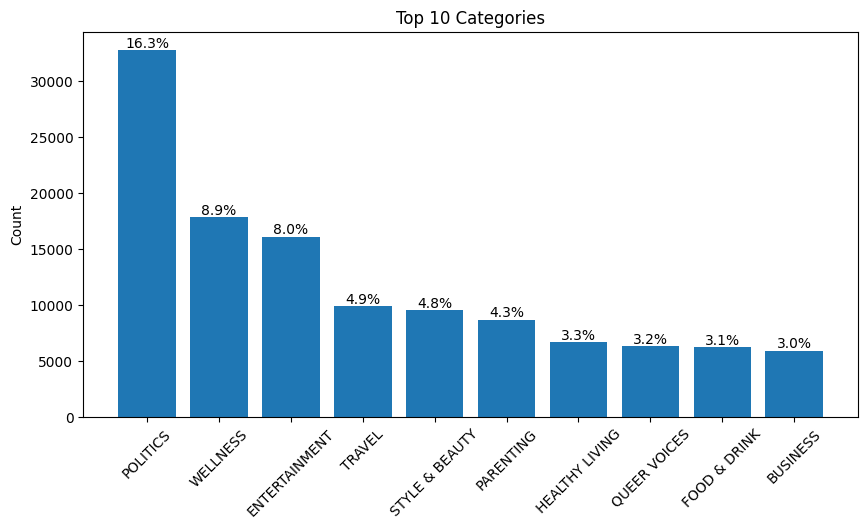

In [6]:
import matplotlib.pyplot as plt

class_counts = df["category"].value_counts()

class_percent = (class_counts / class_counts.sum()) * 100

print("\nTop 10 classes (with %):")
for cat in class_counts.head(10).index:
    count = class_counts[cat]
    pct = class_percent[cat]
    print(f"{cat}: {count} ({pct:.2f}%)")

print("\nTotal number of classes:", df["category"].nunique())

top10 = class_counts.head(10)
top10_pct = class_percent.head(10)

plt.figure(figsize=(10,5))
bars = plt.bar(top10.index, top10.values)

for i, bar in enumerate(bars):
    height = bar.get_height()
    pct = top10_pct.iloc[i]
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"{pct:.1f}%", ha='center', va='bottom')

plt.title("Top 10 Categories")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [7]:
# (5) Create reproducible splits

from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# train 80/20 split 
train_df, temp_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=RANDOM_SEED)

# set validation and test set to 10%
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=RANDOM_SEED)

print("\nSplit sizes:")
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))


Split sizes:
Train: 160148
Validation: 20018
Test: 20019


In [9]:
# (6) Document your pipeline

from datasets import Dataset

# convert splits to hugging face datasets
train_dataset = Dataset.from_pandas(train_df)
val_dataset   = Dataset.from_pandas(val_df)
test_dataset  = Dataset.from_pandas(test_df)

# apply tokenizer
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset   = val_dataset.map(tokenize_function, batched=True)
test_dataset  = test_dataset.map(tokenize_function, batched=True)

# set pytorch 
columns_to_return = ["input_ids", "attention_mask", "label"]

train_dataset.set_format(type="torch", columns=columns_to_return)
val_dataset.set_format(type="torch", columns=columns_to_return)
test_dataset.set_format(type="torch", columns=columns_to_return)

Map: 100%|██████████| 20019/20019 [00:02<00:00, 7151.39 examples/s]


### Graded Questions (5 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible. 

1. **Data Loading and Cleaning:**
   Describe how you loaded your dataset and the key cleaning steps you implemented (e.g., handling missing data, normalizing formats, or removing duplicates).



1.1. **Your answer here:**



2. **Preprocessing and Standardization:**
   Summarize your preprocessing pipeline. Include any normalization, tokenization, resizing, or augmentation steps, and explain why each was necessary for your dataset.
  

1.2. **Your answer here:**



3. **Train/Validation/Test Splits:**
   Explain how you divided your data into subsets, including the split ratios, random seed, and any stratification or leakage checks you used to verify correctness.


1.3. **Your answer here:**



4. **Class Distribution and Balance:**
   Report your label counts and describe any class imbalances you observed. If applicable, explain how you addressed them (e.g., weighting, oversampling, or data augmentation).


1.4. **Your answer here:**



## Problem 2 – Baseline Model (20 pts)

### Goal

Build and train a **simple, fully functional baseline model** to establish a reference level of performance for your dataset.
This baseline will help you evaluate whether later architectures and fine-tuning steps actually improve results.


### Steps to Follow

1. **Construct a baseline model**

   * **Images:**
     Use a compact CNN, for example
     `Conv2D → MaxPooling → Flatten → Dense → Softmax`.
   * **Text:**
     Use a small embedding-based classifier such as
     `Embedding → GlobalAveragePooling → Dense → Softmax`.
   * Keep the model small enough to train in minutes on Colab.

2. **Compile the model**

   * Optimizer: `Adam` or `AdamW`.
   * Loss: `categorical_crossentropy` (for multi-class).
   * Metrics: at least `accuracy`; add `F1` if appropriate.

3. **Train and validate**

   * Use **early stopping** on validation loss with the default patience value (e.g., 5 epochs).
   * Record number of epochs trained and total runtime.

4. **Visualize results**

   * Plot **training vs. validation accuracy and loss**.
   * Carefully observe: does the model underfit, overfit, or generalize reasonably?

5. **Report baseline performance**

   * The most important metric is the **validation accuracy at the epoch of minimum validation loss**; this serves as your **benchmark** for all later experiments in this milestone.
   * Evaluate on the **test set** and record final metrics.

In [11]:
# Your code here; add as many cells as you need but make it clear what the structure is. 

# create data loaders 

from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [12]:
# (1) Construct a Baseline Model

import torch
import torch.nn as nn

class BaselineClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.fc = nn.Linear(embed_dim, num_classes)
    
    def forward(self, input_ids, attention_mask=None):
        x = self.embedding(input_ids)                 # (B, L, D)
        x = x.mean(dim=1)                             # Global Average Pooling
        logits = self.fc(x)                           # (B, num_classes)
        return logits

vocab_size = tokenizer.vocab_size
embed_dim = 128
num_classes = len(label_2)

model = BaselineClassifier(vocab_size, embed_dim, num_classes)

In [ ]:
# convert class weights into a tensor 

weights_list = [class_weights[i] for i in range(len(class_weights))]
class_weights_tensor = torch.tensor(weights_list, dtype=torch.float)

weights_list = [class_weights[i] for i in range(len(class_weights))]
class_weights_tensor = torch.tensor(weights_list, dtype=torch.float)

In [ ]:
# (2) Compile the model 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# using class weights to address class imbalance
weights_list = [class_weights[i] for i in range(len(class_weights))]
class_weights_tensor = torch.tensor(weights_list, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

In [16]:
# (3) Train and Validate 

from time import time

EPOCHS = 20
patience = 5

best_val_loss = float("inf")
patience_counter = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

start_time = time()

for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc = correct / total

    # validation
    model.eval()
    val_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}:")
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f}, Val Acc:   {val_acc:.4f}")

    # early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

end_time = time()
print(f"\nTraining time: {(end_time - start_time):.2f} seconds")

Epoch 1:
Train Loss: 3.1276, Train Acc: 0.2876
Val Loss:   2.5877, Val Acc:   0.4200
Epoch 2:
Train Loss: 2.2188, Train Acc: 0.4771
Val Loss:   2.0511, Val Acc:   0.4895
Epoch 3:
Train Loss: 1.7730, Train Acc: 0.5385
Val Loss:   1.8267, Val Acc:   0.5304
Epoch 4:
Train Loss: 1.5246, Train Acc: 0.5773
Val Loss:   1.7328, Val Acc:   0.5438
Epoch 5:
Train Loss: 1.3508, Train Acc: 0.6083
Val Loss:   1.6828, Val Acc:   0.5562
Epoch 6:
Train Loss: 1.2097, Train Acc: 0.6351
Val Loss:   1.6644, Val Acc:   0.5553
Epoch 7:
Train Loss: 1.0878, Train Acc: 0.6586
Val Loss:   1.6649, Val Acc:   0.5622
Epoch 8:
Train Loss: 0.9806, Train Acc: 0.6807
Val Loss:   1.6799, Val Acc:   0.5684
Epoch 9:
Train Loss: 0.8825, Train Acc: 0.7023
Val Loss:   1.7083, Val Acc:   0.5726
Epoch 10:
Train Loss: 0.7965, Train Acc: 0.7224
Val Loss:   1.7451, Val Acc:   0.5688
Epoch 11:
Train Loss: 0.7177, Train Acc: 0.7414
Val Loss:   1.7942, Val Acc:   0.5689
Early stopping triggered.

Training time: 814.19 seconds


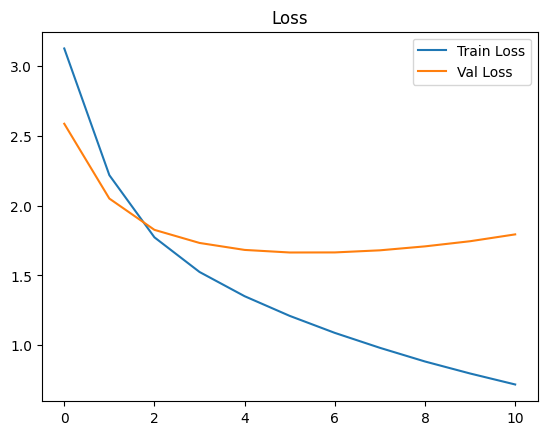

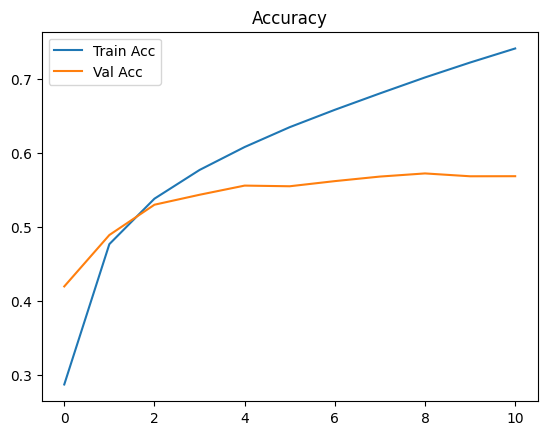

In [17]:
# (4) Visualize Results 

# Loss
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss")
plt.show()

# Accuracy
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy")
plt.show()

In [18]:
# (5) Report baseline performance 

model.load_state_dict(best_model_state)

model.eval()
correct, total = 0, 0

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["label"].to(device)

        outputs = model(input_ids)
        preds = torch.argmax(outputs, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.5628


### Graded Questions (5 pts each)

1. **Model Architecture:**
   Describe your baseline model and justify why this structure suits your dataset.

2.1. **Your answer here:**



2. **Training Behavior:**
   Summarize the model’s training and validation curves. What trends did you observe?

2.2. **Your answer here:**



  3. **Baseline Metrics:**
   Report validation and test metrics. What does this performance tell you about dataset difficulty?

2.3. **Your answer here:**



  4. **Reflection:**
   What are the main limitations of your baseline? Which specific improvements (depth, regularization, pretraining) would you try next?
  

2.4. **Your answer here:**



## Problem 3 – Custom (Original) Model (20 pts)

### Goal

Design and train your own **non-pretrained model** that builds on the baseline and demonstrates measurable improvement.
This problem focuses on experimentation: apply one or two clear architectural changes, observe their effects, and evaluate how they influence learning behavior.


### Steps to Follow

1. **Modify or extend your baseline architecture**

   * Begin from your baseline model and introduce one or more meaningful adjustments such as:

     * Adding **dropout** or **batch normalization** for regularization.
     * Increasing **depth** (extra convolutional or dense layers).
     * Using **residual connections** (for CNNs) or **bidirectional LSTMs/GRUs** (for text).
     * Trying alternative activations like `ReLU`, `LeakyReLU`, or `GELU`.
   * Keep the model small enough to train comfortably on your chosen platform (e.g., Colab)

2. **Observe what specific limitations you want to address**

   * Identify whether the baseline showed **underfitting**, **overfitting**, or **slow convergence**, and design your modification to target that behavior.
   * Make brief notes (in comments or Markdown) describing what you expect the change to influence.

3. **Train and evaluate under the same conditions**

   * Use the **same data splits**, **random seed**, and **metrics** as in Problem 2.
   * Apply **early stopping** on validation loss.
   * Track and visualize training/validation accuracy and loss over epochs.

4. **Compare outcomes to the baseline**

   * Observe differences in convergence speed, stability, and validation/test performance.
   * Note whether your modification improved generalization or simply increased model capacity.

### Graded Questions (5 pts each)

1. **Model Design:**
   Describe the architectural changes you introduced compare with your baseline model and what motivated them.

3.1. **Your answer here:**



2. **Training Results:**
   Present key validation and test metrics. Did your modifications improve performance?

3.2. **Your answer here:**



3. **Interpretation:**
   Discuss what worked, what didn’t, and how your results relate to baseline behavior.

3.3. **Your answer here:**



4. **Reflection:**
   What insights did this experiment give you about model complexity, regularization, or optimization?

3.4. **Your answer here:**



## Problem 4 – Pretrained Model (Transfer Learning) (20 pts)

### Goal

Apply **transfer learning** to see how pretrained knowledge improves accuracy, convergence speed, and generalization.
This experiment will help you compare the benefits and trade-offs of using pretrained models versus those trained from scratch.


### Steps to Follow

1. **Select a pretrained architecture**

   * **Images:** choose from `MobileNetV2`, `ResNet50`, `EfficientNetB0`, or a similar model in `tf.keras.applications`.
   * **Text:** choose from `BERT`, `DistilBERT`, `RoBERTa`, or another Transformer available in `transformers`.

2. **Adapt the model for your dataset**

   * Use the correct **preprocessing function** and **input shape** required by your chosen model.
   * Replace the top layer with your own **classification head** (e.g., `Dense(num_classes, activation='softmax')`).

3. **Apply transfer learning**

   * Choose an appropriate **training strategy** for your pretrained model. Options include:

     * **Freezing** the pretrained base and training only a new classification head.
     * **Partially fine-tuning** selected upper layers of the base model.
     * **Full fine-tuning** (all layers trainable) with a reduced learning rate.
   * Adjust your learning rate schedule to match your strategy (e.g., smaller LR for fine-tuning).
   * Observe how your chosen approach affects **validation loss**, **training time**, and **model stability**.

4. **Train and evaluate under consistent conditions**

   * Use the same **splits**, **metrics**, and **evaluation protocol** as in earlier problems.
   * Record training duration, validation/test performance, and any resource constraints (GPU memory, runtime).

5. **Compare and analyze**

   * Observe how transfer learning changes both **performance** and **efficiency** relative to your baseline and custom models.
   * Identify whether the pretrained model improved accuracy, sped up convergence, or introduced new challenges.


### Graded Questions (5 pts each)

1. **Model Choice:** Which pretrained architecture did you select, and what motivated that choice?

4.1. **Your answer here:**



2. **Fine-Tuning Plan:** Describe your fine-tuning strategy and why you chose it. 

4.2. **Your answer here:**



3. **Performance:** Report key metrics and compare them with your baseline and custom models.

4.3. **Your answer here:**



4. **Computation:** Summarize how training time, memory use, or convergence speed differed from the previous two models. 

4.4. **Your answer here:**



## Problem 5 – Comparative Evaluation and Discussion (20 pts)

### Goal

Compare your **baseline**, **custom**, and **pretrained** models to evaluate how design choices affected performance, efficiency, and generalization.
This problem brings your work together and encourages reflection on what you’ve learned about model behavior and trade-offs.

**Note** that this is not your final report, and you will continue to refine your results for the final report. 

### Steps to Follow

1. **Compile key results**

   * Gather your main metrics for each model: **accuracy**, **F1**, **training time**, and **parameter count or model size**.
   * Ensure all numbers come from the same evaluation protocol and test set.

2. **Visualize the comparison**

   * Present results in a **single, well-organized chart or table**.
   * Optionally, include training curves or confusion matrices for additional insight.

3. **Analyze comparative performance**

   * Observe which model performed best by your chosen metric(s).
   * Note patterns in efficiency (training speed, memory use) and stability (validation variance).

4. **Inspect model behavior**

   * Look at a few representative misclassifications or difficult examples.
   * Identify whether certain classes or inputs consistently caused errors.

5. **Plan forward improvements**

   * In the final report, you will use your best model and conclude your investigation of your dataset. Based on your observations, decide on a model and next steps for refining your approach in the final project (e.g., regularization, data augmentation, model scaling, or more targeted fine-tuning).

### Graded Questions (4 pts each)

1. **Summary Table and Performance Analysis:** Present a clear quantitative comparison of all three models. Which model achieved the best overall results, and what factors contributed to its success?

5.1. **Your answer here:**



2. **Trade-Offs:** Discuss how complexity, accuracy, and efficiency balanced across your models.

5.2. **Your answer here:**



3. **Error Patterns:** Describe the types of examples or classes that remained challenging for all models.

5.3. **Your answer here:**



4. **Next Steps:** Based on these findings, decide on a model to go forward with and outline your plan for improving that model. 


5.4 **Your answer here:**



### Final Question: Describe what use you made of generative AI tools in preparing this Milestone. 

**AI Question: Your answer here:**